ARTI308 - Machine Learning

# Linear Regression Lab on Ecommerce Customers Dataset

**Let's get started!**

In this notebook, we apply the same Linear Regression workflow from the lab to a new dataset: **Ecommerce Customers**.

Tasks covered:
- Load the dataset into a DataFrame
- Explore the data (`head`, `info`, `describe`)
- Perform basic data cleaning if needed
- Apply feature engineering if applicable
- Prepare the data for modeling
- Train a model using **Linear Regression**
- Evaluate the model performance

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Load and Explore the Data

In [49]:
# Load the Ecommerce Customers dataset
ecom = pd.read_csv("Ecommerce Customers")

ecom.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [50]:
ecom.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [51]:
ecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [52]:
ecom.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [53]:
ecom.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

# Exploratory Data Analysis

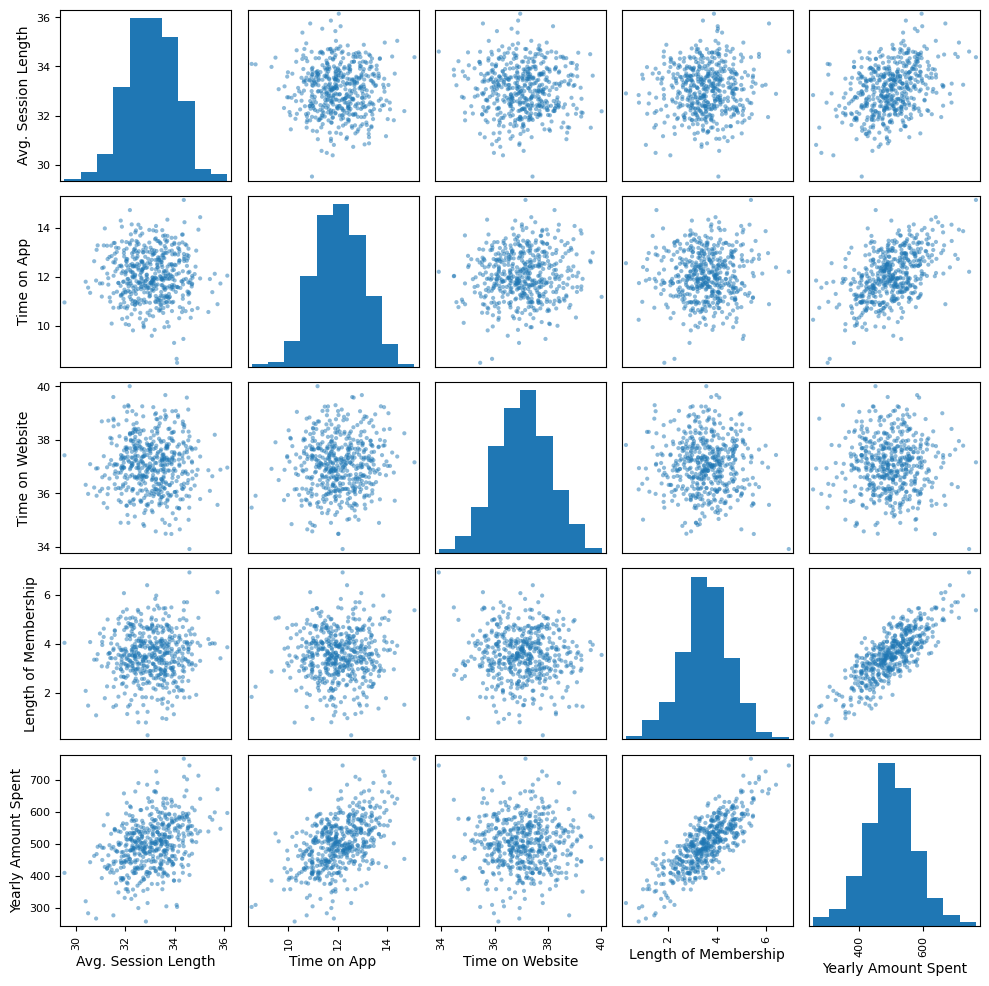

In [54]:
pd.plotting.scatter_matrix(ecom.select_dtypes(include='number'), figsize=(10, 10))
plt.tight_layout()

Text(0.5, 1.0, 'Distribution of Yearly Amount Spent')

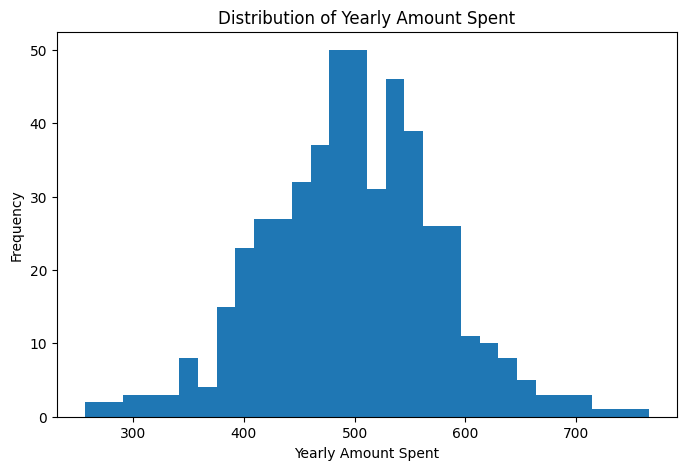

In [55]:
plt.figure(figsize=(8,5))
plt.hist(ecom['Yearly Amount Spent'], bins=30)
plt.xlabel('Yearly Amount Spent')
plt.ylabel('Frequency')
plt.title('Distribution of Yearly Amount Spent')

<Axes: >

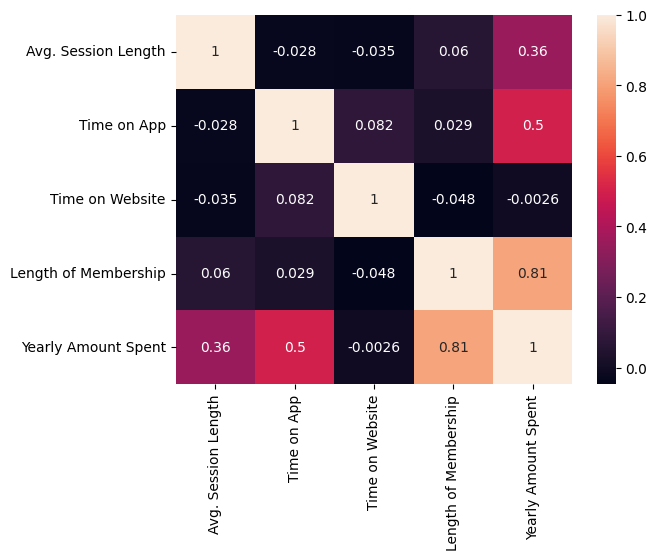

In [56]:
sns.heatmap(ecom.select_dtypes(include='number').corr(), annot=True)

## Data Cleaning and Feature Engineering

In [57]:
# Check for missing values
print(ecom.isnull().sum())

# Drop non-numeric columns that are not useful for Linear Regression
ecom_clean = ecom.drop(['Email', 'Address', 'Avatar'], axis=1)

# Features and target
X = ecom_clean[['Avg. Session Length', 'Time on App', 'Time on Website',
                'Length of Membership']]
y = ecom_clean['Yearly Amount Spent']

ecom_clean.head()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


## Train Test Split

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Creating and Training the Model

In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
lm = LinearRegression()

In [62]:
lm.fit(X_train,y_train)

LinearRegression()

## Model Coefficients

In [63]:
# print the intercept
print(lm.intercept_)

-1050.6536746645725


In [64]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,25.724256
Time on App,38.597135
Time on Website,0.459148
Length of Membership,61.674732


Interpreting the coefficients:

- Positive coefficients mean that as the feature increases, the predicted yearly amount spent also increases.
- Larger coefficient values indicate a stronger effect on the target variable, assuming other features stay constant.

Linear Regression is a good choice here because the target variable (**Yearly Amount Spent**) is continuous.

## Predictions from our Model

In [65]:
predictions = lm.predict(X_test)

Text(0.5, 1.0, 'Actual vs Predicted Values')

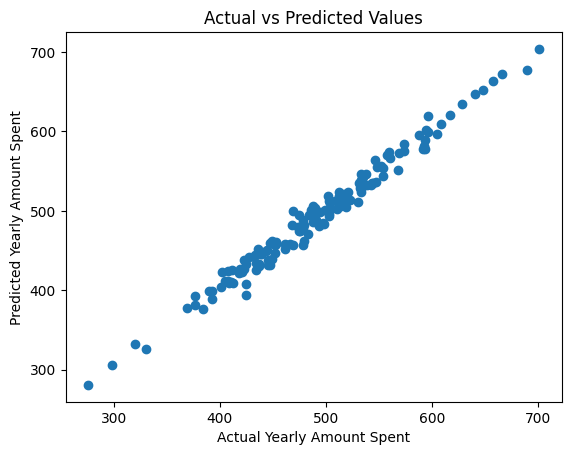

In [66]:
plt.scatter(y_test, predictions)
plt.xlabel('Actual Yearly Amount Spent')
plt.ylabel('Predicted Yearly Amount Spent')
plt.title('Actual vs Predicted Values')

**Residual Histogram**

Text(0.5, 1.0, 'Residual Histogram')

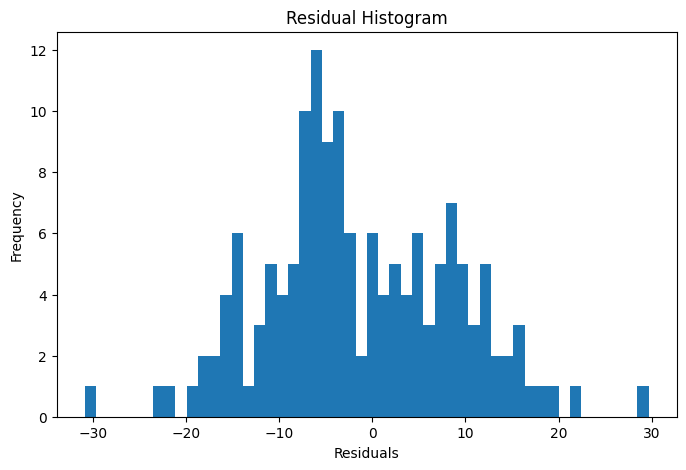

In [67]:
plt.figure(figsize=(8,5))
plt.hist(y_test - predictions, bins=50)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Histogram')

## Regression Evaluation Metrics

In [68]:
from sklearn import metrics

In [69]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2 Score:', metrics.r2_score(y_test, predictions))

MAE: 8.426091641432116
MSE: 103.91554136503333
RMSE: 10.193897260863155
R2 Score: 0.9808757641125855


The Linear Regression model performs very well on the Ecommerce Customers dataset.
A high R² score and relatively low error values indicate that the model can predict customer yearly spending accurately.